## **Etapa 2 del proyecto. La tarea de clasificación: árboles de decisión y K-vecinos más cercanos**
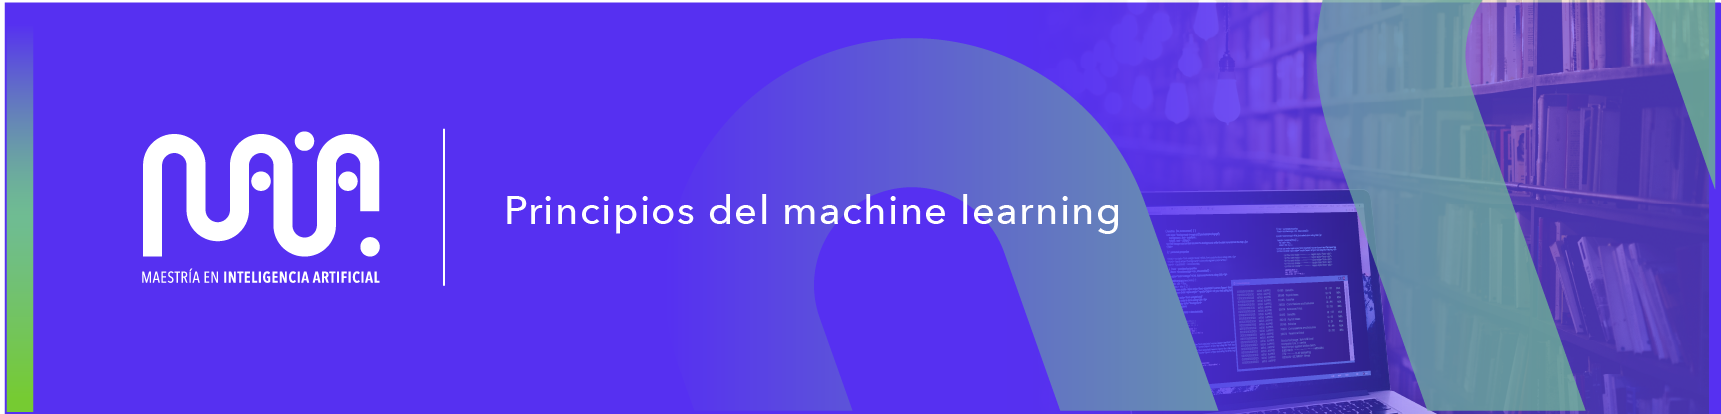
## **Sergio Masso Giraldo**
-------------------------------------------------
## **Contextualizacion:**
La hipertensión arterial es uno de los principales factores de riesgo para las enfermedades cardiovasculares, las cuales, a su vez, son una de las causas principales de morbilidad y mortalidad a nivel mundial[1]. La detección temprana de esta afección representa un gran reto, ya que sus síntomas a menudo pasan desapercibidos y el diagnóstico se realiza con frecuencia en etapas avanzadas. Esta situación resalta la importancia de encontrar soluciones que apoyen en la identificación precoz de la hipertensión.

Este proyecto tiene como objetivo desarrollar modelos predictivos basados en datos que permitan estimar el riesgo de hipertensión en pacientes. La finalidad es doble: por un lado, facilitar la identificación temprana de casos y, por otro, identificar los factores clave que influyen en el desarrollo de la enfermedad. Una herramienta de este tipo sería de gran valor para los profesionales de la salud ya que les permitiría fortalecer las campañas y programas de prevención, así como diseñar estrategias de educación en salud más personalizadas.

-------------------------------------------------

## **Objetivos**
- Aplicar técnicas de clasificación basadas en árboles de decisión y K-vecinos más cercanos para construir modelos predictivos que permitan identificar el riesgo de desarrollar hipertensión.
- Identificar los factores más relevantes que influyen en el desarrollo de la hipertensión a partir del análisis de los datos.

El conjunto de datos incluye información demográfica, de hábitos de vida y antecedentes médicos de individuos, como edad, índice de masa corporal (BMI), consumo de tabaco, así como la presencia de enfermedad cardíaca

## **Desarrollo**
## **Exploración y perfilamiento de los datos (EDA)**

De acuerdo con los datos proporcionados y la problemática planteada, el primer paso en cualquier proyecto de Machine Learning es llevar a cabo un data quality assessment, evaluando la integridad, consistencia y representatividad del conjunto de datos. Este proceso permite identificar valores faltantes, outliers, sesgos y posibles errores de captura que puedan comprometer la validez del modelo.

Posteriormente, se procede con el preprocesamiento y la transformación de los datos, incluyendo tareas de normalización, codificación de variables categóricas y generación de nuevas características mediante feature engineering. Estas etapas son fundamentales para enriquecer la representación de los datos y mejorar la capacidad predictiva del modelo.

Finalmente, todas estas operaciones se integran dentro de un pipeline de procesamiento y modelado, lo que asegura reproducibilidad, escalabilidad y trazabilidad en el flujo de trabajo. De esta manera, el modelo recibe datos limpios, estructurados y enriquecidos, garantizando predicciones más robustas, confiables y alineadas con los objetivos del negocio.


In [1]:
# Instalacion de librerias
!pip install scikit-learn pandas numpy matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pandas-profiling 3.2.0 requires joblib~=1.1.0, but you have joblib 1.5.3 which is incompatible.

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [58]:
# Importacion de librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, validation_curve
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [ ]:
# Lectura de la base de datos o datos entregados
path_data = 'Data/_787b0ca34e1a43b08344c5a74a88a186_Datos_hipertension.csv'
# especificar una codificación que maneje caracteres especiales (latin1, cp1252, etc.)
data_raw = pd.read_csv(path_data, sep=';', encoding='latin1')
data_raw.head()

,Edad,Ingesta_Sal,Nivel_Stres,Colesterol,Duración_Sueño,BMI,Medicación,Historia_Familiar,Actividad_Fisica,Fumador,Glucosa,Enfermedad_Corazon,Hipertension
0,69,8.0,9,242.4,6.4,25.8,Ninguna,Si,Baja,No,127.8,Si,Si
1,32,11.7,10,177.2,5.4,23.4,Ninguna,No,Baja,No,105.9,No,No
2,78,9.5,3,193.0,7.1,18.7,Ninguna,No,Moderada,No,102.7,No,No
3,38,10.0,10,268.1,4.2,22.1,InhibidorACE,No,Baja,No,99.0,No,Si
4,41,9.8,1,175.3,5.8,16.2,Otro,No,Moderada,No,101.5,No,No


In [10]:
# Creacion de una copia de los datos para trabajar
data = data_raw.copy()
data.head()

,Edad,Ingesta_Sal,Nivel_Stres,Colesterol,Duración_Sueño,BMI,Medicación,Historia_Familiar,Actividad_Fisica,Fumador,Glucosa,Enfermedad_Corazon,Hipertension
0,69,8.0,9,242.4,6.4,25.8,Ninguna,Si,Baja,No,127.8,Si,Si
1,32,11.7,10,177.2,5.4,23.4,Ninguna,No,Baja,No,105.9,No,No
2,78,9.5,3,193.0,7.1,18.7,Ninguna,No,Moderada,No,102.7,No,No
3,38,10.0,10,268.1,4.2,22.1,InhibidorACE,No,Baja,No,99.0,No,Si
4,41,9.8,1,175.3,5.8,16.2,Otro,No,Moderada,No,101.5,No,No


In [12]:
data.shape

(1990, 13)

In [13]:
# Información general del dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1990 entries, 0 to 1989
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Edad                1990 non-null   int64  
 1   Ingesta_Sal         1990 non-null   float64
 2   Nivel_Stres         1990 non-null   int64  
 3   Colesterol          1990 non-null   float64
 4   Duración_Sueño      1990 non-null   float64
 5   BMI                 1990 non-null   float64
 6   Medicación          1990 non-null   object 
 7   Historia_Familiar   1990 non-null   object 
 8   Actividad_Fisica    1990 non-null   object 
 9   Fumador             1990 non-null   object 
 10  Glucosa             1990 non-null   float64
 11  Enfermedad_Corazon  1990 non-null   object 
 12  Hipertension        1990 non-null   object 
dtypes: float64(5), int64(2), object(6)
memory usage: 202.2+ KB


Al analizar la primera información del dataset, se observa que contamos con 1.990 registros y 13 columnas que describen las características de cada paciente. Dentro de estas variables, se identifican 6 de tipo categórico que, dado que la problemática consiste en predecir si un cliente presenta hipertensión (clasificación binaria: Sí/No), deberán ser transformadas a representaciones numéricas mediante técnicas de codificación, exceptuando la variable objetivo (Hipertensión), que se mantendrá en su formato categórico para preservar la naturaleza del problema.

Como parte del data quality assessment, se valida que todas las variables incluidas en el diccionario de datos aportan información relevante y significativa para el modelo, por lo que no será necesario eliminar ninguna columna. Este proceso asegura que el conjunto de datos sea íntegro y representativo.

Posteriormente, se aplicarán técnicas de feature engineering para enriquecer la representación de las variables, optimizando la capacidad predictiva del modelo. Finalmente, todas estas etapas se integrarán dentro de un pipeline de procesamiento y modelado, garantizando reproducibilidad, trazabilidad y escalabilidad en el flujo de trabajo. De esta manera, el modelo recibirá datos limpios, estructurados y enriquecidos, lo que permitirá obtener predicciones más robustas y confiables.

Este texto ya está en un tono de documentación técnica, como si fuera parte de un notebook profesional o README de proyecto ML.
¿Quieres que lo estructure directamente en formato de secciones tipo documentación (ejemplo: Data Quality Assessment, Feature Engineering, Pipeline Architecture) para que quede listo como parte de un informe o notebook?


In [15]:
# Validacion de datos faltantes y duplicados
print("Datos faltantes por columna:")
print(data.isnull().sum())
print("\n")
print("Datos duplicados:")
print(data.duplicated().sum())

Datos faltantes por columna:
Edad                  0
Ingesta_Sal           0
Nivel_Stres           0
Colesterol            0
Duración_Sueño        0
BMI                   0
Medicación            0
Historia_Familiar     0
Actividad_Fisica      0
Fumador               0
Glucosa               0
Enfermedad_Corazon    0
Hipertension          0
dtype: int64


Datos duplicados:
4


In [16]:
# Descripcion estadistica de las variables numericas
data.describe()

,Edad,Ingesta_Sal,Nivel_Stres,Colesterol,Duración_Sueño,BMI,Glucosa
count,1990.000000,1990.000000,1990.000000,1990.000000,1990.000000,1990.000000,1990.000000
mean,50.379397,8.531608,4.974372,209.526935,6.452613,26.013869,105.642211
std,19.439669,1.994245,3.144396,75.791456,1.540354,4.507425,22.541122
min,18.000000,2.500000,0.000000,121.200000,1.500000,11.900000,70.000000
25%,34.000000,7.200000,2.000000,181.325000,5.400000,23.000000,89.200000
50%,50.000000,8.500000,5.000000,204.400000,6.500000,25.900000,102.500000
75%,67.000000,9.900000,8.000000,231.700000,7.500000,29.100000,119.875000
max,84.000000,16.400000,10.000000,2360.000000,11.400000,41.900000,196.100000


De acuerdo con la información suministrada, se identificaron 4 registros duplicados en el dataset, lo que implica una ligera reducción en el número total de observaciones, sin afectar de manera significativa la representatividad del conjunto de datos. En cuanto a la variable de edad, se observa un rango entre 18 y 84 años, lo cual resulta consistente con la población objetivo.

Respecto a las variables relacionadas con ingesta de sal y nivel de estrés, no se evidencian valores atípicos que requieran imputación. Sin embargo, se detectan pacientes con niveles elevados de colesterol. Estos valores podrían corresponder tanto a outliers estadísticos como a datos clínicamente válidos, por lo que se realizara una exploración más detallada de su distribución y de la relación con las demás variables.

## **Visualizacion de los datos**

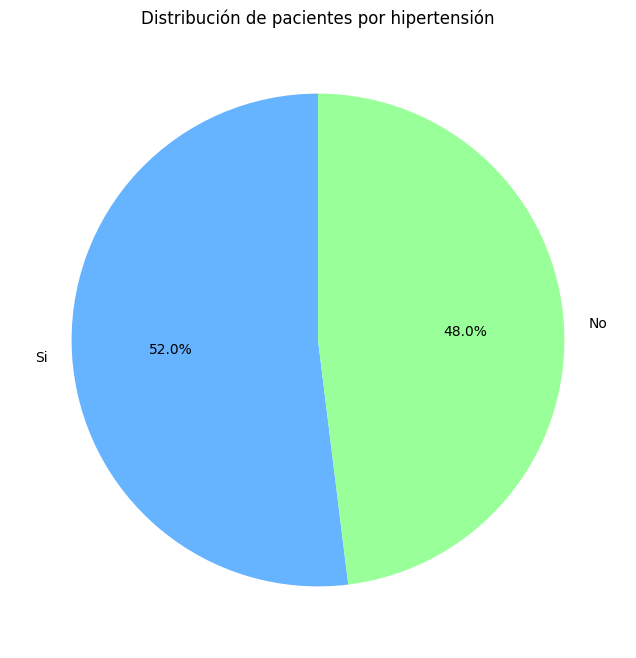

In [25]:
# Analisis exploratorio de la variable objetivo
# Conteo de la variable objetivo
counts = data['Hipertension'].value_counts()

# Gráfico circular
plt.figure(figsize=(8, 8))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#99ff99'])
plt.title('Distribución de pacientes por hipertensión')
plt.show()


Del análisis preliminar se observa que más de la mitad de los pacientes en el dataset presentan hipertensión. Este hallazgo indica que la distribución de la variable objetivo (Hipertensión: Sí/No) se encuentra relativamente balanceada y no existe un sesgo significativo hacia ninguna de las dos clases.

Este equilibrio es positivo para el proceso de modelado, ya que reduce la necesidad de aplicar técnicas de resampling (como oversampling o undersampling) o de generar datos sintéticos para igualar las clases. En consecuencia, el modelo podrá entrenarse sobre un conjunto representativo, evitando distorsiones en el aprendizaje y favoreciendo la obtención de predicciones más confiables

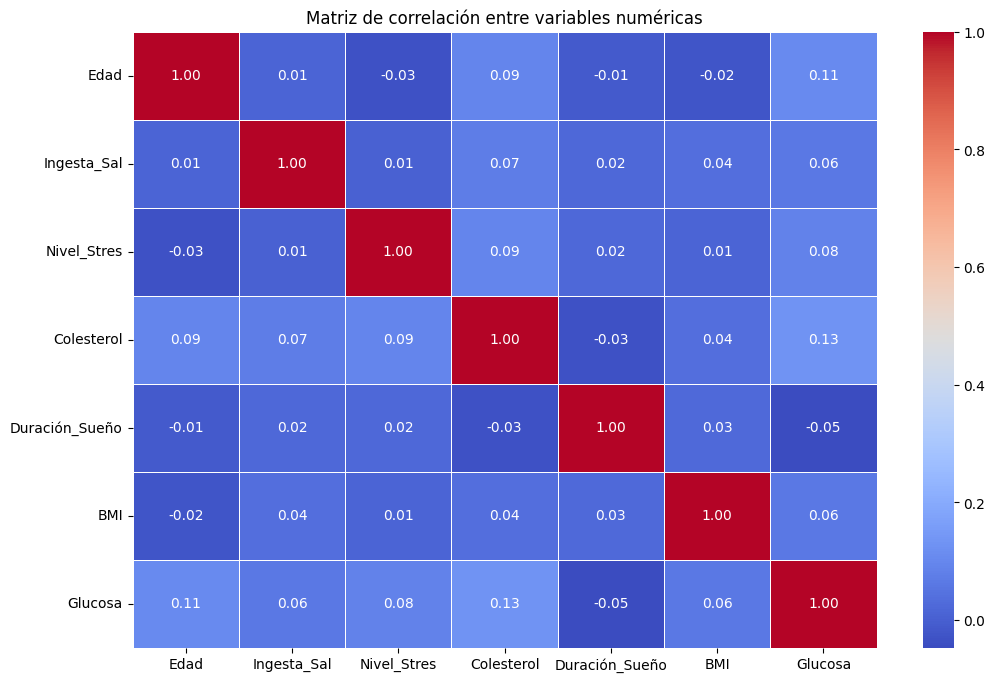

In [26]:
# Calcular la matriz de correlación
corr = data.corr(numeric_only=True)

# Configurar el gráfico
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de correlación entre variables numéricas')
plt.show()

Del análisis de la matriz de correlación se observa cierta tendencia que sugiere que, a medida que aumenta la edad, la duración del sueño tiende a disminuir, mientras que los niveles de glucosa y colesterol muestran una ligera tendencia a incrementarse.

Si bien estas correlaciones son débiles y no permiten establecer conclusiones deterministas, sí aportan indicios relevantes que justifican una exploración más detallada.

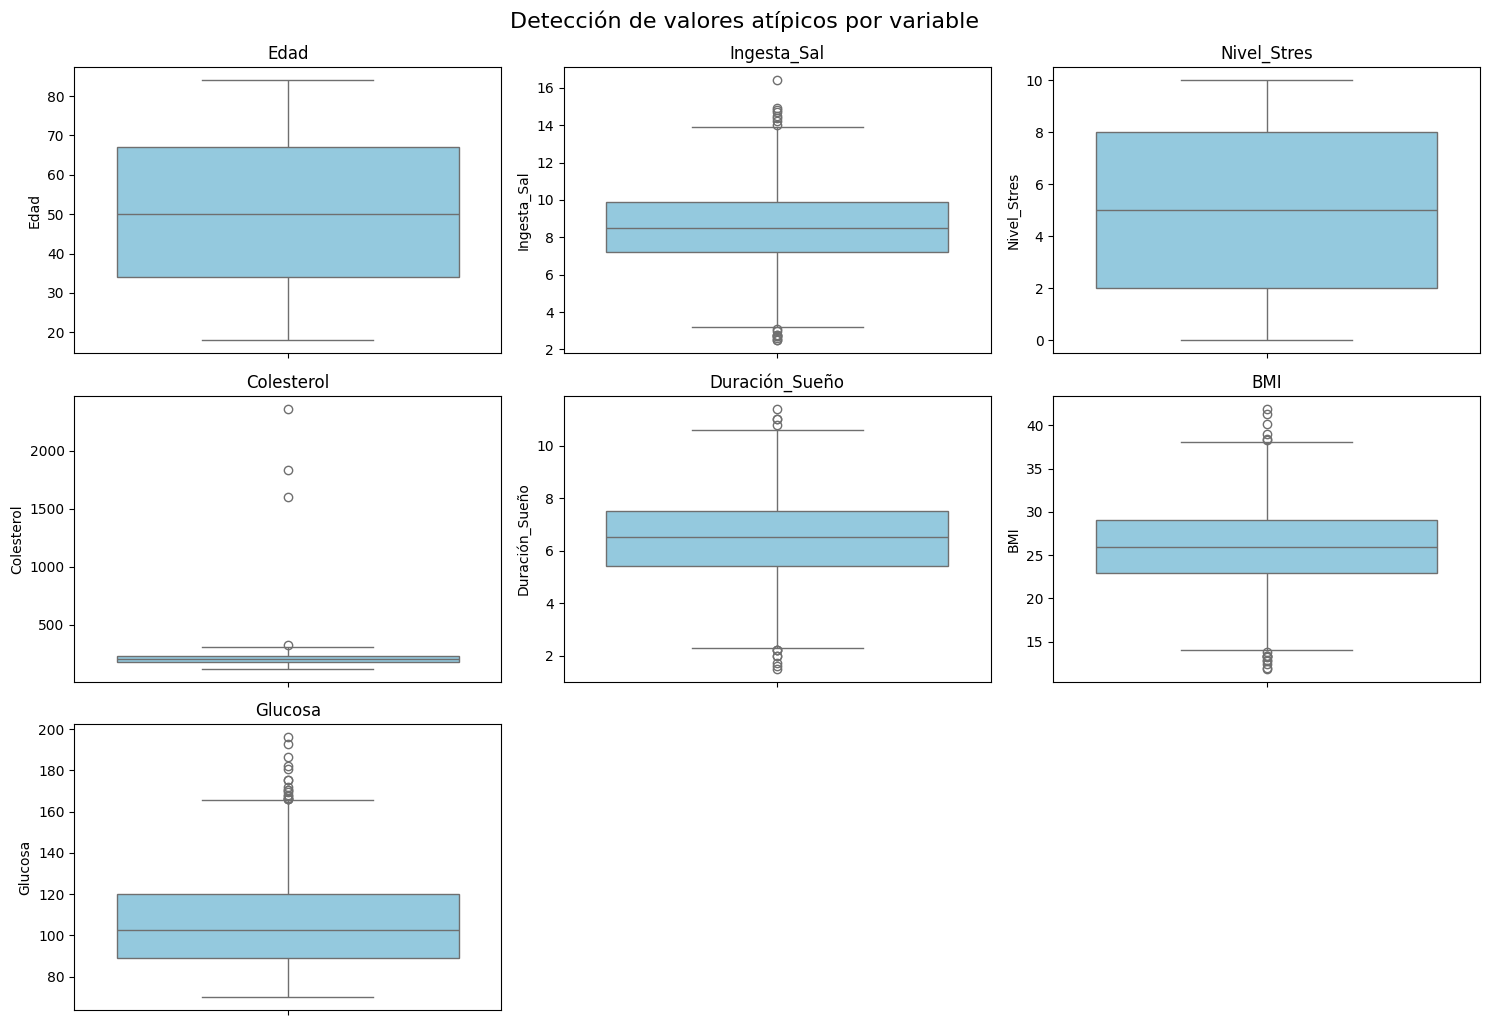

In [27]:
# Graficar de boxplot para cada variable numérica
# Seleccionamos solo las columnas numéricas con la función select_dtypes de pandas
numeric_cols = data.select_dtypes(include=['int64','float64']).columns

# Definimos el número de columnas y filas para la matriz de subplots
n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols # Calcula el número de filas necesarias

plt.figure(figsize=(15, 10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(y=data[col], color='skyblue')
    plt.title(col)
    plt.tight_layout()

plt.suptitle('Detección de valores atípicos por variable', fontsize=16, y=1.02)
plt.show()


Para finalizar el análisis exploratorio de los datos, se confirma la presencia de valores atípicos en variables como ingesta de sal, colesterol, duración del sueño, índice de masa corporal (BMI) y glucosa. Sin embargo, dado que no se cuenta con un conocimiento experto en la temática clínica subyacente, sería inapropiado asumir que estos registros corresponden a errores y eliminarlos de manera automática, ya que podrían representar casos reales y relevantes dentro de la población estudiada.

En consecuencia, se optará por mantener estos valores y aplicar, en caso de ser requerido por el modelo, técnicas de estandarización y normalización que permitan mitigar su impacto en el entrenamiento. Este enfoque asegura que el pipeline de procesamiento preserve la integridad de la información y, al mismo tiempo, garantice que el modelo pueda aprender de manera robusta sin que los outliers distorsionen los resultados.


## **Limpieza de los datos – Pipeline**

Con base en los análisis realizados, se define un **pipeline de preprocesamiento** que permitirá automatizar el proceso de limpieza y ajuste de variables, asegurando reproducibilidad y consistencia en el modelado. Las decisiones tomadas son las siguientes:

- **Eliminación de duplicados**  
  Se removerán los registros duplicados, ya que mantenerlos podría afectar la consistencia del dataset y sesgar las predicciones del modelo.

- **Manejo de valores faltantes**  
  No se realizará imputación, dado que el dataset no presenta valores nulos ni faltantes.

- **Codificación de variables categóricas**  
  Se aplicará **OneHotEncoder** como técnica de *feature engineering* para transformar las variables categóricas en representaciones numéricas.  
  Este paso es indispensable, ya que los algoritmos de *scikit-learn* requieren que todas las variables sean numéricas. La codificación se integrará dentro del pipeline mediante un objeto de la clase `OneHotEncoder()`.

- **Estandarización de variables numéricas**  
  Dado que se han identificado valores atípicos en varias variables, se incluirá un paso de **RobustScaler** en lugar de StandardScaler.  
  Este método utiliza la mediana y el rango intercuartílico (IQR), lo que lo hace menos sensible a la influencia de outliers. De esta manera, se asegura un preprocesamiento más robusto y estable, especialmente útil para algoritmos sensibles a la escala como **KNN**, manteniendo un flujo homogéneo y confiable.

In [29]:
# Eliminacion de valores duplicados antes de realizar el pipeline
data = data.drop_duplicates()
data.shape

(1986, 13)

### **Transformación de variables categóricas**
Usaremos de sklearn.preprocessing el metodo o libreria OneHotEncoder la cual permite transformar variables categóricas en representaciones numéricas, de manera que puedan ser utilizadas por algoritmos de Machine Learning que requieren entradas numéricas, asignandola a una variable llamada encoder haciendo referencia a este proceso, dentro de OneHotEncoder usaremos sparse_output=False para luego implementarlo en el pipeline ya que nos devolvera un array NumPy.

In [ ]:
encoder = OneHotEncoder(sparse_output=False) # Se guarda el encoder para usarlo posteriormente en el pipeline

### **Estandarización de variables numéricas**

Dentro del pipeline de preprocesamiento se incluirá un paso de **escalado robusto** mediante el uso de `RobustScaler`. A diferencia de `StandardScaler`, que utiliza la media y la desviación estándar y resulta sensible a la presencia de valores atípicos, `RobustScaler` emplea la mediana y el rango intercuartílico (IQR) para transformar las variables numéricas.  

Este enfoque permite reducir el impacto de los outliers en el proceso de estandarización, asegurando que las variables mantengan una escala homogénea sin que los valores extremos distorsionen el entrenamiento. La inclusión de este paso es especialmente útil para algoritmos sensibles a la escala, como **KNN**, y garantiza un flujo de preprocesamiento más estable y confiable.

In [31]:
scaler = RobustScaler() # Se guarda el scaler para usarlo posteriormente en el pipeline

### Definicion de variables para el pipeline

In [33]:
# Variables numéricas: su tipo es entero o flotante
numeric_features = ['Edad', 'Ingesta_Sal', 'Nivel_Stres', 'Colesterol', 'Duración_Sueño', 'BMI', 'Glucosa']
# Variables categóricas: su tipo no es numérico
categorical_features = ['Medicación', 'Historia_Familiar', 'Actividad_Fisica', 'Fumador', 'Enfermedad_Corazon']

# Veremos variables para los dos tipos
print(f"Variables numéricas:\n{numeric_features}")
print(f"\nVariables categóricas:\n{categorical_features}")

Variables numéricas:
['Edad', 'Ingesta_Sal', 'Nivel_Stres', 'Colesterol', 'Duración_Sueño', 'BMI', 'Glucosa']

Variables categóricas:
['Medicación', 'Historia_Familiar', 'Actividad_Fisica', 'Fumador', 'Enfermedad_Corazon']


In [34]:
# Definimos una variable imputer, usamos el metodo ColumnTranformer para realizar tranformaciones a las columnas, dentro de este
# Se llama tranformers indicando el tipo de tranformacion, se define que las variables num y cat y su tipo de transformacion seguido
# de la columnas o nombres de las columnas que queremos transformar, verbose es para mantener los mismos nombres de las columnas

imputer = ColumnTransformer(
    transformers=[
    # your code here
    ("num",scaler,numeric_features),
    ("cat",encoder,categorical_features)
    ],
    verbose_feature_names_out=False
)

In [43]:
# Definimos un Pipline para cada modelo, dentro de este se llama el preprocesador (imputer) y el modelo a usar, 
# en este caso se usara DecisionTreeClassifier y KNeighborsClassifier

# Modelo de árbol de decisión
Tree_Classifier = DecisionTreeClassifier(random_state=77)

pipeline_dt = Pipeline(steps=[
    ('transformer', imputer),
    ('model', Tree_Classifier)
])
pipeline_dt


Pipeline(steps=[('transformer',
                 ColumnTransformer(transformers=[('num', RobustScaler(),
                                                  ['Edad', 'Ingesta_Sal',
                                                   'Nivel_Stres', 'Colesterol',
                                                   'Duración_Sueño', 'BMI',
                                                   'Glucosa']),
                                                 ('cat',
                                                  OneHotEncoder(sparse_output=False),
                                                  ['Medicación',
                                                   'Historia_Familiar',
                                                   'Actividad_Fisica',
                                                   'Fumador',
                                                   'Enfermedad_Corazon'])],
                                   verbose_feature_names_out=False)),
                ('model', DecisionTreeClassifier(random_state=77))])

In [44]:
# Modelo de KNN
KNN_Classifier = KNeighborsClassifier()

pipeline_knn = Pipeline(steps=[
    ('transformer', imputer),
    ('model', KNN_Classifier)
])
pipeline_knn

Pipeline(steps=[('transformer',
                 ColumnTransformer(transformers=[('num', RobustScaler(),
                                                  ['Edad', 'Ingesta_Sal',
                                                   'Nivel_Stres', 'Colesterol',
                                                   'Duración_Sueño', 'BMI',
                                                   'Glucosa']),
                                                 ('cat',
                                                  OneHotEncoder(sparse_output=False),
                                                  ['Medicación',
                                                   'Historia_Familiar',
                                                   'Actividad_Fisica',
                                                   'Fumador',
                                                   'Enfermedad_Corazon'])],
                                   verbose_feature_names_out=False)),
                ('model', KNeighborsClassifier())])

## **Modelo de árboles de decisión**

In [45]:
# División de los datos en entrenamiento y prueba, se define un test_size del 20% y un random_state para reproducibilidad 77
train, test = train_test_split(data, test_size=0.2, random_state=77)
train.head()

,Edad,Ingesta_Sal,Nivel_Stres,Colesterol,Duración_Sueño,BMI,Medicación,Historia_Familiar,Actividad_Fisica,Fumador,Glucosa,Enfermedad_Corazon,Hipertension
1444,37,6.7,3,194.7,8.6,21.1,BloqueadorBeta,No,Alta,No,70.0,No,No
1917,34,9.9,2,192.8,4.8,21.4,InhibidorACE,No,Baja,Si,105.7,No,No
342,75,7.3,2,209.4,5.9,35.2,Ninguna,Si,Alta,No,131.7,No,Si
740,50,6.8,7,213.3,4.5,22.5,BloqueadorBeta,Si,Moderada,No,117.2,No,No
1706,49,6.5,0,189.8,5.7,21.0,Ninguna,No,Moderada,Si,132.3,No,No


In [46]:
# Separación de las variables predictoras (X) y la variable objetivo (y) para el conjunto de entrenamiento
x_train = train.drop(['Hipertension'],axis=1)
y_train = train['Hipertension']
# Separación de las variables predictoras (X) y la variable objetivo (y) para el conjunto de prueba
x_test = test.drop(['Hipertension'],axis=1)
y_test = test['Hipertension']

## **Búsqueda de hiperparámetros con un pipeline**

Construcción de un modelo de árboles de decisión. GridSeacrhCV, con el siguiente espacio de búsqueda: {'criterion':['gini', 'entropy'],'max_depth':[4,6,8,10,12],'min_samples_split':[3, 4, 5]}. 

In [47]:
# Definimos la grilla de parámetros para el modelo de árbol de decisión
param_grid_dt = {
    'model__criterion': ['gini', 'entropy'],
    'model__max_depth': [4, 6, 8, 10, 12],
    'model__min_samples_split': [3, 4, 5]
}

In [48]:
# Al igual que en la búsqueda únicamente sobre los parámetros del modelo, 
# definiremos un objeto de la clase KFold() para realizar la validación cruzada con 5 subconjuntos de datos:
kfold = KFold(n_splits=5, shuffle=True, random_state=77)

In [49]:
# Finalmente, definiremos la búsqueda con un objeto de la clase GridSearchCV() 
# usando el pipeline pipeline, el espacio de búsqueda param_grid y la técnica de 
# validación cruzada kfold:

grid_search_dt = GridSearchCV(estimator=pipeline_dt, param_grid=param_grid_dt, cv=kfold, n_jobs=-1, verbose=1)
grid_search_dt

GridSearchCV(cv=KFold(n_splits=5, random_state=77, shuffle=True),
             estimator=Pipeline(steps=[('transformer',
                                        ColumnTransformer(transformers=[('num',
                                                                         RobustScaler(),
                                                                         ['Edad',
                                                                          'Ingesta_Sal',
                                                                          'Nivel_Stres',
                                                                          'Colesterol',
                                                                          'Duración_Sueño',
                                                                          'BMI',
                                                                          'Glucosa']),
                                                                        ('cat',
                                                                         OneHotEncoder(sparse_output=False),
                                                                         ['Medicación',
                                                                          'Historia_Familiar',
                                                                          'Actividad_Fisica',
                                                                          'Fumador',
                                                                          'Enfermedad_Corazon'])],
                                                          verbose_feature_names_out=False)),
                                       ('model',
                                        DecisionTreeClassifier(random_state=77))]),
             n_jobs=-1,
             param_grid={'model__criterion': ['gini', 'entropy'],
                         'model__max_depth': [4, 6, 8, 10, 12],
                         'model__min_samples_split': [3, 4, 5]},
             verbose=1)

Ejecutaremos la búsqueda sobre el conjunto de entrenamiento original, que será modificado por el pipeline dt

In [50]:
grid_search_dt.fit(x_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=77, shuffle=True),
             estimator=Pipeline(steps=[('transformer',
                                        ColumnTransformer(transformers=[('num',
                                                                         RobustScaler(),
                                                                         ['Edad',
                                                                          'Ingesta_Sal',
                                                                          'Nivel_Stres',
                                                                          'Colesterol',
                                                                          'Duración_Sueño',
                                                                          'BMI',
                                                                          'Glucosa']),
                                                                        ('cat',
                                                                         OneHotEncoder(sparse_output=False),
                                                                         ['Medicación',
                                                                          'Historia_Familiar',
                                                                          'Actividad_Fisica',
                                                                          'Fumador',
                                                                          'Enfermedad_Corazon'])],
                                                          verbose_feature_names_out=False)),
                                       ('model',
                                        DecisionTreeClassifier(random_state=77))]),
             n_jobs=-1,
             param_grid={'model__criterion': ['gini', 'entropy'],
                         'model__max_depth': [4, 6, 8, 10, 12],
                         'model__min_samples_split': [3, 4, 5]},
             verbose=1)

In [52]:
print("Mejores parámetros: {}".format(grid_search_dt.best_params_))

Mejores parámetros: {'model__criterion': 'entropy', 'model__max_depth': 4, 'model__min_samples_split': 3}


 Para el mejor modelo, se utiliza la entropía como criterio de pureza, una profundidad máxima de 4 y un mínimo de 3 datos para realizar una división, junto con la transformacion definida anteriormente por el analisis en los datos realizada

In [54]:
# Finalmente, se obtiene el mejor modelo a partir del objeto grid_search_dt y se muestra en pantalla:
mejor_pipeline_dt = grid_search_dt.best_estimator_
mejor_pipeline_dt

Pipeline(steps=[('transformer',
                 ColumnTransformer(transformers=[('num', RobustScaler(),
                                                  ['Edad', 'Ingesta_Sal',
                                                   'Nivel_Stres', 'Colesterol',
                                                   'Duración_Sueño', 'BMI',
                                                   'Glucosa']),
                                                 ('cat',
                                                  OneHotEncoder(sparse_output=False),
                                                  ['Medicación',
                                                   'Historia_Familiar',
                                                   'Actividad_Fisica',
                                                   'Fumador',
                                                   'Enfermedad_Corazon'])],
                                   verbose_feature_names_out=False)),
                ('model',
                 DecisionTreeClassifier(criterion='entropy', max_depth=4,
                                        min_samples_split=3,
                                        random_state=77))])

El pipeline que tenemos en la variable `mejor_pipeline_dt` incluye tanto los pasos de preprocesamiento de los datos como el árbol de decisión. Mientras que esto resulta útil para facilitar la predicción de datos

### **Evaluación del mejor modelo dt**
Como ya habiamos separado desde un inicio las variables de test simplemente llamaremos el pipeline definido usando la funcion predict para realizar la evalucion del modelo

In [55]:
y_test_pred = mejor_pipeline_dt.predict(x_test)

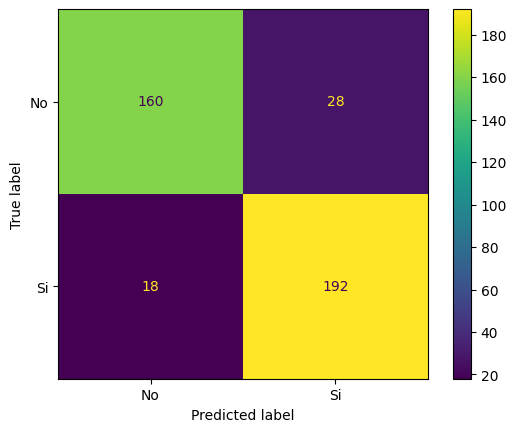

In [56]:
ConfusionMatrixDisplay.from_estimator(mejor_pipeline_dt, x_test, y_test)
plt.show()

In [57]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

          No       0.90      0.85      0.87       188
          Si       0.87      0.91      0.89       210

    accuracy                           0.88       398
   macro avg       0.89      0.88      0.88       398
weighted avg       0.89      0.88      0.88       398



### **Explicacion de las metricas para arbol de decision**
- **Precision:** De acuerdo a los datos presentados el modelo de arbol de decision predijo correctamente que "Si" tienen hipertension en un 87% de los casos, es decir que el 87% de las veces qwe el modelo predijo que si estaba en lo correcto
- **Recall:** En este caso el modelo logra detectar correctamente el 91% de los casos que realmente eran si
- **F1:** 89% indica que el modelo no solo logra encontrar bien los casos positivos si no que tambien tiene buen rendimiento con los negativos
- **Acurracy:** El modelo logra acertar el 88% de todos los ejemplos

## **Modelo utilizando el algoritmo K-vecinos más cercanos**

In [64]:
# Para determinar el número de vecinos utiliza los siguientes valores de K: [1, 2, 3, 4, 5].
param_grid_knn = {
    'model__n_neighbors': [1, 2, 3, 4, 5]
}

In [65]:
# Finalmente, definiremos la búsqueda con un objeto de la clase GridSearchCV() 
# usando el pipeline knn, el espacio de búsqueda param_grid knn y la técnica de 
# validación cruzada kfold ya antes definida:

grid_search_knn = GridSearchCV(estimator=pipeline_knn, param_grid=param_grid_knn, cv=kfold, n_jobs=-1, verbose=1)
grid_search_knn

GridSearchCV(cv=KFold(n_splits=5, random_state=77, shuffle=True),
             estimator=Pipeline(steps=[('transformer',
                                        ColumnTransformer(transformers=[('num',
                                                                         RobustScaler(),
                                                                         ['Edad',
                                                                          'Ingesta_Sal',
                                                                          'Nivel_Stres',
                                                                          'Colesterol',
                                                                          'Duración_Sueño',
                                                                          'BMI',
                                                                          'Glucosa']),
                                                                        ('cat',
                                                                         OneHotEncoder(sparse_output=False),
                                                                         ['Medicación',
                                                                          'Historia_Familiar',
                                                                          'Actividad_Fisica',
                                                                          'Fumador',
                                                                          'Enfermedad_Corazon'])],
                                                          verbose_feature_names_out=False)),
                                       ('model', KNeighborsClassifier())]),
             n_jobs=-1, param_grid={'model__n_neighbors': [1, 2, 3, 4, 5]},
             verbose=1)

In [66]:
grid_search_knn.fit(x_train, y_train)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=77, shuffle=True),
             estimator=Pipeline(steps=[('transformer',
                                        ColumnTransformer(transformers=[('num',
                                                                         RobustScaler(),
                                                                         ['Edad',
                                                                          'Ingesta_Sal',
                                                                          'Nivel_Stres',
                                                                          'Colesterol',
                                                                          'Duración_Sueño',
                                                                          'BMI',
                                                                          'Glucosa']),
                                                                        ('cat',
                                                                         OneHotEncoder(sparse_output=False),
                                                                         ['Medicación',
                                                                          'Historia_Familiar',
                                                                          'Actividad_Fisica',
                                                                          'Fumador',
                                                                          'Enfermedad_Corazon'])],
                                                          verbose_feature_names_out=False)),
                                       ('model', KNeighborsClassifier())]),
             n_jobs=-1, param_grid={'model__n_neighbors': [1, 2, 3, 4, 5]},
             verbose=1)

In [67]:
print("Mejores parámetros knn: {}".format(grid_search_knn.best_params_))

Mejores parámetros knn: {'model__n_neighbors': 5}


Para KNN encontramos que el mejor pipeline debe de ser con 5 n vecinos mas cercanos, usanod las metricas de transoformacion o metodos antes descritos

In [68]:
# Finalmente, se obtiene el mejor modelo a partir del objeto grid_search_dt y se muestra en pantalla:
mejor_pipeline_knn = grid_search_knn.best_estimator_
mejor_pipeline_knn

Pipeline(steps=[('transformer',
                 ColumnTransformer(transformers=[('num', RobustScaler(),
                                                  ['Edad', 'Ingesta_Sal',
                                                   'Nivel_Stres', 'Colesterol',
                                                   'Duración_Sueño', 'BMI',
                                                   'Glucosa']),
                                                 ('cat',
                                                  OneHotEncoder(sparse_output=False),
                                                  ['Medicación',
                                                   'Historia_Familiar',
                                                   'Actividad_Fisica',
                                                   'Fumador',
                                                   'Enfermedad_Corazon'])],
                                   verbose_feature_names_out=False)),
                ('model', KNeighborsClassifier())])

### **Evaluación del mejor modelo knn**
Como ya habiamos separado desde un inicio las variables de test simplemente llamaremos el pipeline definido usando la funcion predict para realizar la evalucion del modelo

In [69]:
y_test_pred_knn = mejor_pipeline_knn.predict(x_test)

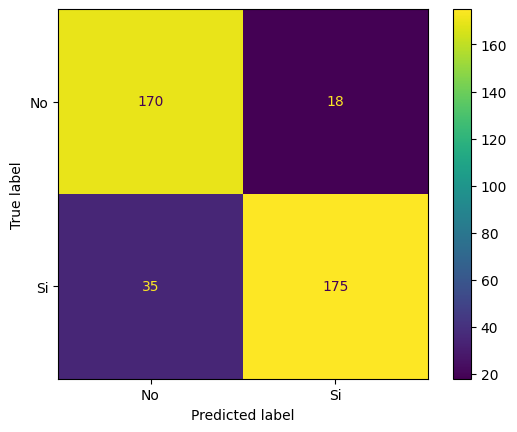

In [71]:
ConfusionMatrixDisplay.from_estimator(mejor_pipeline_knn, x_test, y_test)
plt.show()

In [72]:
print(classification_report(y_test, y_test_pred_knn))

              precision    recall  f1-score   support

          No       0.83      0.90      0.87       188
          Si       0.91      0.83      0.87       210

    accuracy                           0.87       398
   macro avg       0.87      0.87      0.87       398
weighted avg       0.87      0.87      0.87       398



### **Explicación de las métricas para KNN**
- **Precisión:** El modelo de KNN predijo correctamente que los pacientes tenían hipertensión en un **91%** de los casos en los que dijo “Sí”. Esto significa que, cuando el modelo afirma que alguien tiene hipertensión, en la gran mayoría de ocasiones está en lo correcto.  
- **Recall:** El modelo logra detectar correctamente el **83%** de los casos que realmente eran “Sí”. Esto indica que se le escapan algunos positivos, aunque sigue identificando la mayoría.  
- **F1:** El valor de **87%** refleja un buen equilibrio entre precisión y recall. El modelo no solo acierta bastante cuando predice “Sí”, sino que también logra encontrar una proporción considerable de los casos positivos.  
- **Accuracy:** El modelo logra acertar en el **87%** de todos los ejemplos, tanto de la clase “No” como de la clase “Sí”.  

### **Tabla comparativa**

In [78]:
# Definicion de metricas por cada modelo

# Árbol de decisión
reporte_dt = classification_report(y_test, y_test_pred, output_dict=True)
tabla_dt = pd.DataFrame(reporte_dt).transpose()
print("Reporte Árbol de decisión")
print(tabla_dt)

# KNN
reporte_knn = classification_report(y_test, y_test_pred_knn, output_dict=True)
tabla_knn = pd.DataFrame(reporte_knn).transpose()
print("\nReporte KNN")
print(tabla_knn)

tabla_comparativa = pd.DataFrame({
    'Métrica': ['Precision', 'Recall', 'F1-Score', "accuracy_score"],
    'Árbol de decisión': [tabla_dt.loc['Si', 'precision'], tabla_dt.loc['Si', 'recall'], tabla_dt.loc['Si', 'f1-score'], tabla_dt.loc['accuracy', 'precision']],
    'KNN': [tabla_knn.loc['Si', 'precision'], tabla_knn.loc['Si', 'recall'], tabla_knn.loc['Si', 'f1-score'], tabla_knn.loc['accuracy', 'precision']]
})
print("-------------------------------------------------")
print("\nTabla comparativa de métricas para la clase 'Si' (hipertensión):")
print(tabla_comparativa)

Reporte Árbol de decisión
              precision    recall  f1-score     support
No             0.898876  0.851064  0.874317  188.000000
Si             0.872727  0.914286  0.893023  210.000000
accuracy       0.884422  0.884422  0.884422    0.884422
macro avg      0.885802  0.882675  0.883670  398.000000
weighted avg   0.885079  0.884422  0.884187  398.000000

Reporte KNN
              precision    recall  f1-score     support
No             0.829268  0.904255  0.865140  188.000000
Si             0.906736  0.833333  0.868486  210.000000
accuracy       0.866834  0.866834  0.866834    0.866834
macro avg      0.868002  0.868794  0.866813  398.000000
weighted avg   0.870143  0.866834  0.866906  398.000000
-------------------------------------------------

Tabla comparativa de métricas para la clase 'Si' (hipertensión):
          Métrica  Árbol de decisión       KNN
0       Precision           0.872727  0.906736
1          Recall           0.914286  0.833333
2        F1-Score           0.89

### **Comparación con el árbol de decisión**
- El árbol de decisión tenía un **recall más alto (91%)**, lo que significa que detectaba más casos positivos.  
- El KNN, en cambio, tiene una **precisión más alta (91%)**, lo que significa que cuando predice “Sí”, se equivoca menos.  
- Ambos modelos tienen un rendimiento global muy similar (**88% vs 87% de accuracy**), pero cada uno destaca en un aspecto distinto: el árbol en **sensibilidad**, el KNN en **precisión**.  

### **Conclusión**
El modelo de KNN es sólido y confiable, con un buen balance general. Su mayor fortaleza está en la **confianza de sus predicciones positivas**, mientras que el árbol de decisión sobresale en la **capacidad de detectar la mayoría de los casos positivos**. La elección entre ambos dependerá del objetivo:  
- Si se busca **minimizar los falsos positivos**, KNN es más adecuado.  
- Si se busca **detectar la mayor cantidad de casos posibles**, el árbol de decisión es la mejor opción.

## **intervalos de confianza mediante bootstrapping**
Estimación de intervalos de confianza mediante bootstrapping. Investiga la técnica de bootstrapping y utilízala para estimar un intervalo de confianza del 95% para al menos una de las métricas (por ejemplo, exactitud) con base en el modelo de mejor desempeño. Debes explicar brevemente el procedimiento utilizado e interpretar el intervalo obtenido en el contexto del problema.

Utilizando el modelo de árboles de decisión, hasta con una profundidad de tres (3), genera las reglas que permitan determinar cuándo un paciente está en riesgo de sufrir hipertensión (no es necesario volver a construir el árbol).

In [79]:
from sklearn.tree import export_text

# Definir el árbol de decisión a partir del mejor pipeline
arbol = mejor_pipeline_dt.named_steps['model']

# Exportar las reglas con profundidad máxima de 3
reglas = export_text(arbol, feature_names=mejor_pipeline_dt[:-1].get_feature_names_out(), max_depth=3)
print(reglas)

|--- Colesterol <= 0.02
|   |--- Glucosa <= 0.35
|   |   |--- Colesterol <= -0.33
|   |   |   |--- Duración_Sueño <= -0.79
|   |   |   |   |--- class: No
|   |   |   |--- Duración_Sueño >  -0.79
|   |   |   |   |--- class: No
|   |   |--- Colesterol >  -0.33
|   |   |   |--- Fumador_No <= 0.50
|   |   |   |   |--- class: No
|   |   |   |--- Fumador_No >  0.50
|   |   |   |   |--- class: No
|   |--- Glucosa >  0.35
|   |   |--- Colesterol <= -0.40
|   |   |   |--- Duración_Sueño <= 0.88
|   |   |   |   |--- class: No
|   |   |   |--- Duración_Sueño >  0.88
|   |   |   |   |--- class: Si
|   |   |--- Colesterol >  -0.40
|   |   |   |--- Glucosa <= 0.80
|   |   |   |   |--- class: Si
|   |   |   |--- Glucosa >  0.80
|   |   |   |   |--- class: Si
|--- Colesterol >  0.02
|   |--- Colesterol <= 0.50
|   |   |--- Glucosa <= 0.37
|   |   |   |--- Enfermedad_Corazon_Si <= 0.50
|   |   |   |   |--- class: Si
|   |   |   |--- Enfermedad_Corazon_Si >  0.50
|   |   |   |   |--- class: Si
|   |   |

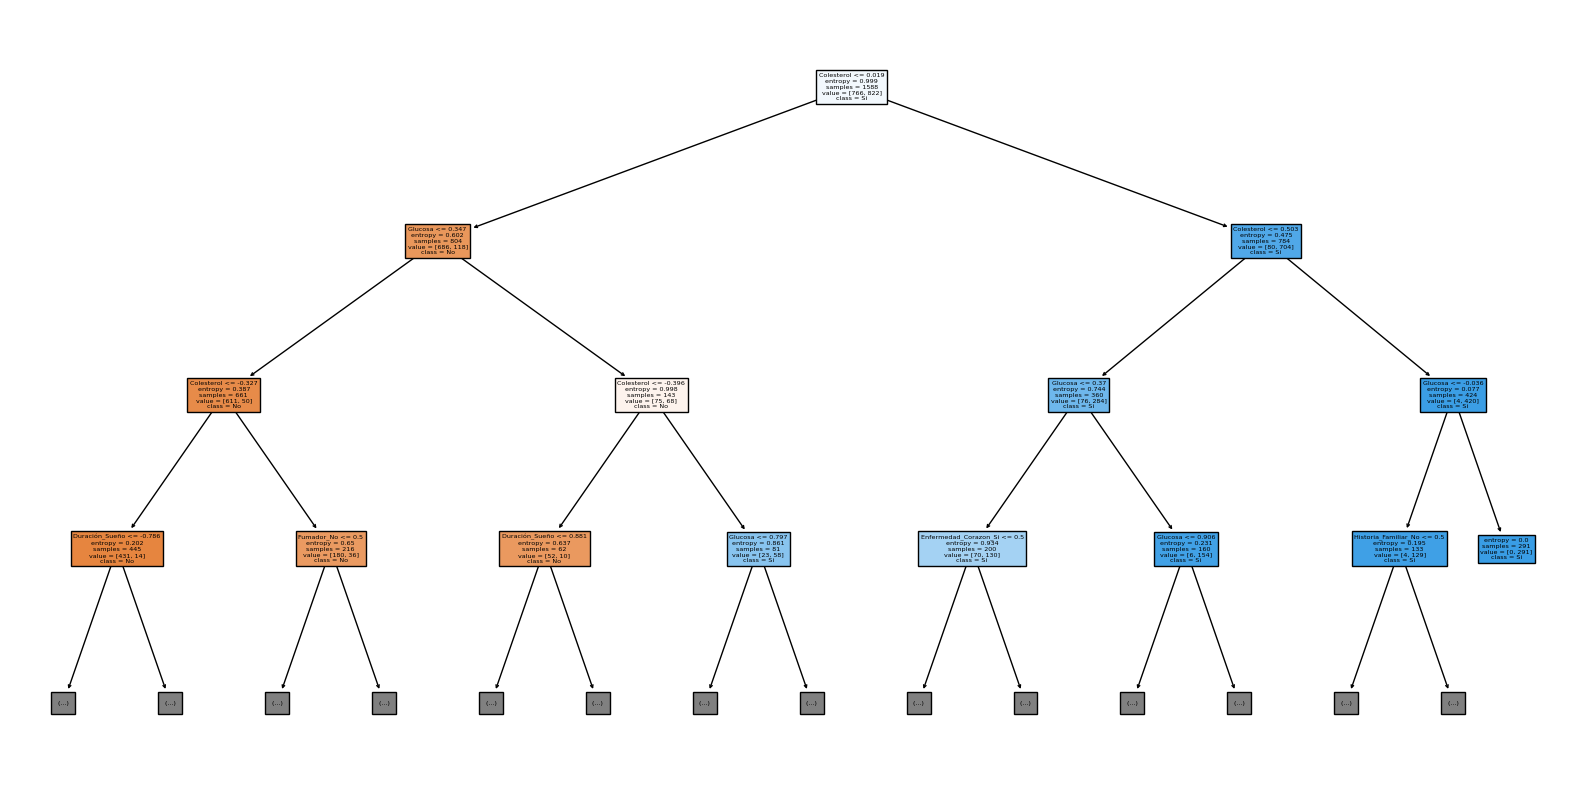

In [80]:
from sklearn.tree import plot_tree

# Graficar el árbol con profundidad máxima de 3
plt.figure(figsize=(20,10))
plot_tree(
    arbol,
    feature_names=mejor_pipeline_dt[:-1].get_feature_names_out(),
    class_names=["No", "Si"],
    filled=True,
    max_depth=3
)
plt.show()


## Análisis de resultados
Una vez construido los modelos, deberías estar en capacidad de responder estas preguntas:

- ¿Qué puedes decir de los valores de las métricas recall y precisión para cada una de las clases en cada modelo? ¿Cuál de estás métricas consideras que es más importante con base en la descripción del problema?

- ¿Consideras que el rendimiento de los modelos es adecuado? Si no es así, ¿Cómo podrían mejorarse los resultados?

- ¿Cuáles son las variables más significativas según el mejor modelo basado en árboles de decisión? Reflexiona sobre cómo este nuevo conocimiento podría ayudar a tomar decisiones en el contexto del problema.

- Si ambos modelos presentan resultados similares en las métricas de desempeño, ¿Cuál seleccionarías considerando el contexto clínico del problema? Justifica tu elección.

- ¿Qué indica el intervalo de confianza estimado sobre la estabilidad y confiabilidad del modelo seleccionado?